<a href="https://colab.research.google.com/github/jpaduchi44/Case-Studies-on-Well-Known-Datasets/blob/main/Iris_dataset_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study on the Iris Dataset

The present case study explores the Iris dataset by R. A. Fischer. It contains data about the width and length (in cm) of the sepal and petal of 150 iris plants belonging to 3 different types/classes, which are Iris setosa, Iris verisicolor and Iris virginica. [1]

Firstly, an exploratory analysis of the dataset will be presented, in order to gain a preliminary understanding of the different features of the dataset. Secondly, basic statistical inference will be conducted with the goal of more general results about the distribution of the features of each class of Iris and how they compare to each other. Lastly, a few classic machine learning classification models will be trained on the data.

## References

[1] Fisher, R. (1936). Iris [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56C76.

## Exploratory Data Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris

In [2]:
data = load_iris(as_frame=True)
iris_data = data.frame
setosa = iris_data[iris_data['target']==0]
versicolor = iris_data[iris_data['target']==1]
virginica = iris_data[iris_data['target']==2]

In [3]:
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
iris_data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
print(iris_data['target'].value_counts())
print(iris_data['target'].value_counts(normalize=True))

target
0    50
1    50
2    50
Name: count, dtype: int64
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


In [11]:
# Descriptive statistics by class
iris_data.groupby('target').describe().T

target                           0          1          2
sepal length (cm) count  50.000000  50.000000  50.000000
                  mean    5.006000   5.936000   6.588000
                  std     0.352490   0.516171   0.635880
                  min     4.300000   4.900000   4.900000
                  25%     4.800000   5.600000   6.225000
                  50%     5.000000   5.900000   6.500000
                  75%     5.200000   6.300000   6.900000
                  max     5.800000   7.000000   7.900000
sepal width (cm)  count  50.000000  50.000000  50.000000
                  mean    3.428000   2.770000   2.974000
                  std     0.379064   0.313798   0.322497
                  min     2.300000   2.000000   2.200000
                  25%     3.200000   2.525000   2.800000
                  50%     3.400000   2.800000   3.000000
                  75%     3.675000   3.000000   3.175000
                  max     4.400000   3.400000   3.800000
petal length (cm) count  50.000000  50.000000  50.000000
                  mean    1.462000   4.260000   5.552000
                  std     0.173664   0.469911   0.551895
                  min     1.000000   3.000000   4.500000
                  25%     1.400000   4.000000   5.100000
                  50%     1.500000   4.350000   5.550000
                  75%     1.575000   4.600000   5.875000
                  max     1.900000   5.100000   6.900000
petal width (cm)  count  50.000000  50.000000  50.000000
                  mean    0.246000   1.326000   2.026000
                  std     0.105386   0.197753   0.274650
                  min     0.100000   1.000000   1.400000
                  25%     0.200000   1.200000   1.800000
                  50%     0.200000   1.300000   2.000000
                  75%     0.300000   1.500000   2.300000
                  max     0.600000   1.800000   2.500000

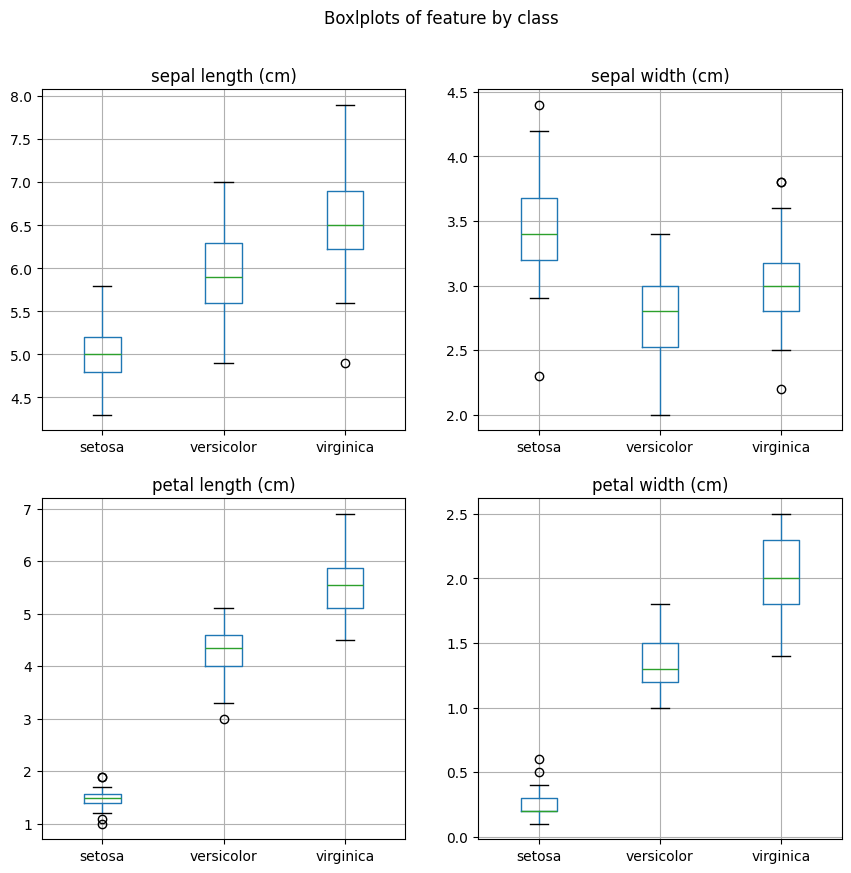

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for feat, ax in zip(data.feature_names, axes):
  iris_data.boxplot(by='target', column=feat, ax=ax)
  ax.set_xticklabels(data.target_names)
  ax.set_xlabel('')
fig.suptitle('Boxlplots of feature by class')
plt.show()

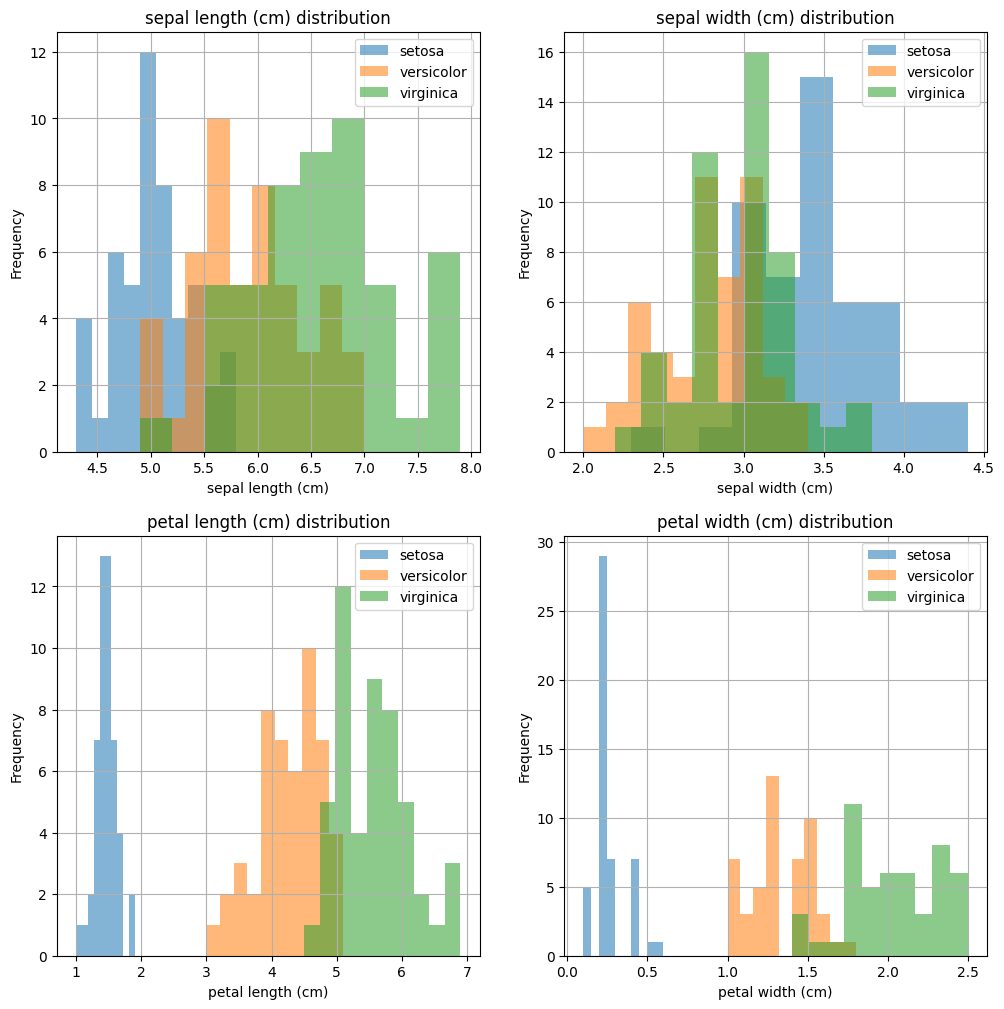

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()
for feat, ax in zip(data.feature_names, axes):
  for i in iris_data['target'].unique():
    iris_data.loc[iris_data['target']==i, feat].hist(ax=ax, alpha=0.55, label=data.target_names[i])
    ax.set_title(f'{feat} distribution')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
  ax.legend()
plt.show()

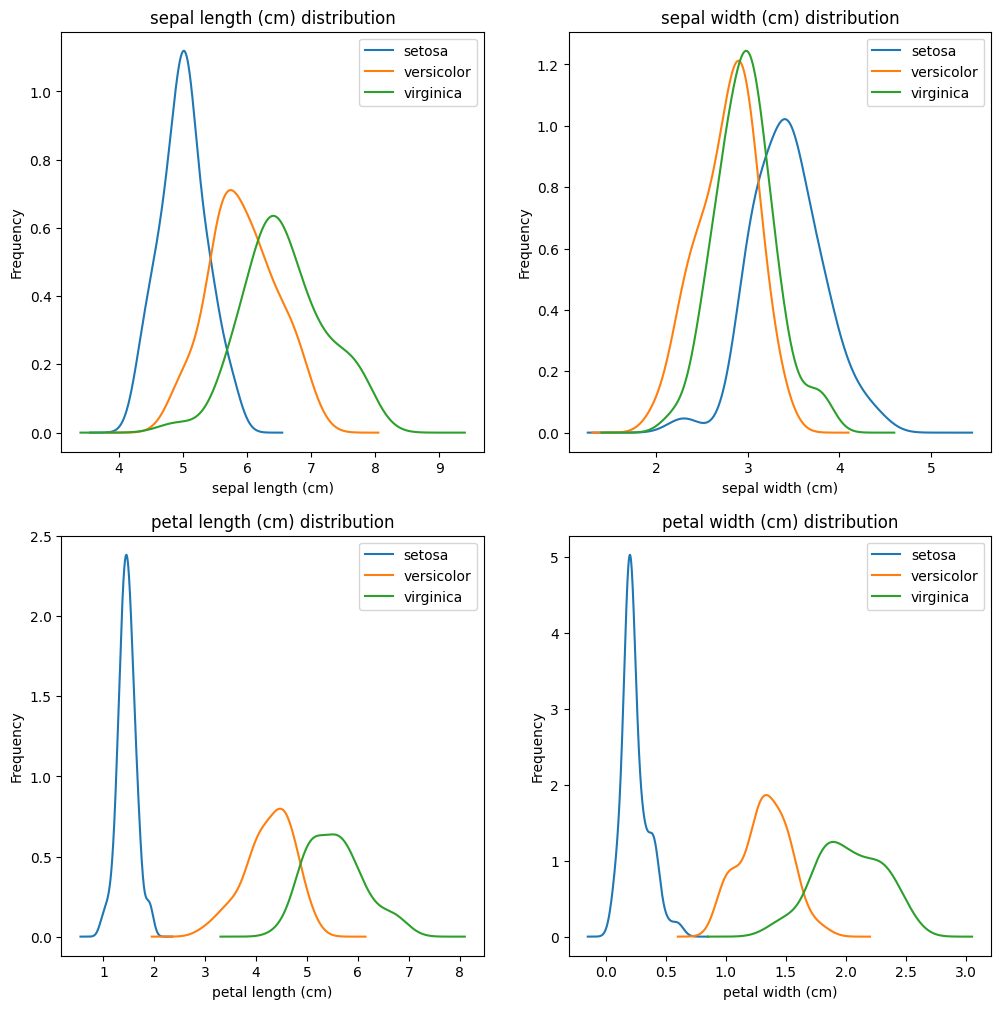

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()
for feat, ax in zip(data.feature_names, axes):
  for i in iris_data['target'].unique():
    iris_data.loc[iris_data['target']==i, feat].plot(kind='kde', ax=ax, label=data.target_names[i], legend=True)
    ax.set_title(f'{feat} distribution')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
plt.show()

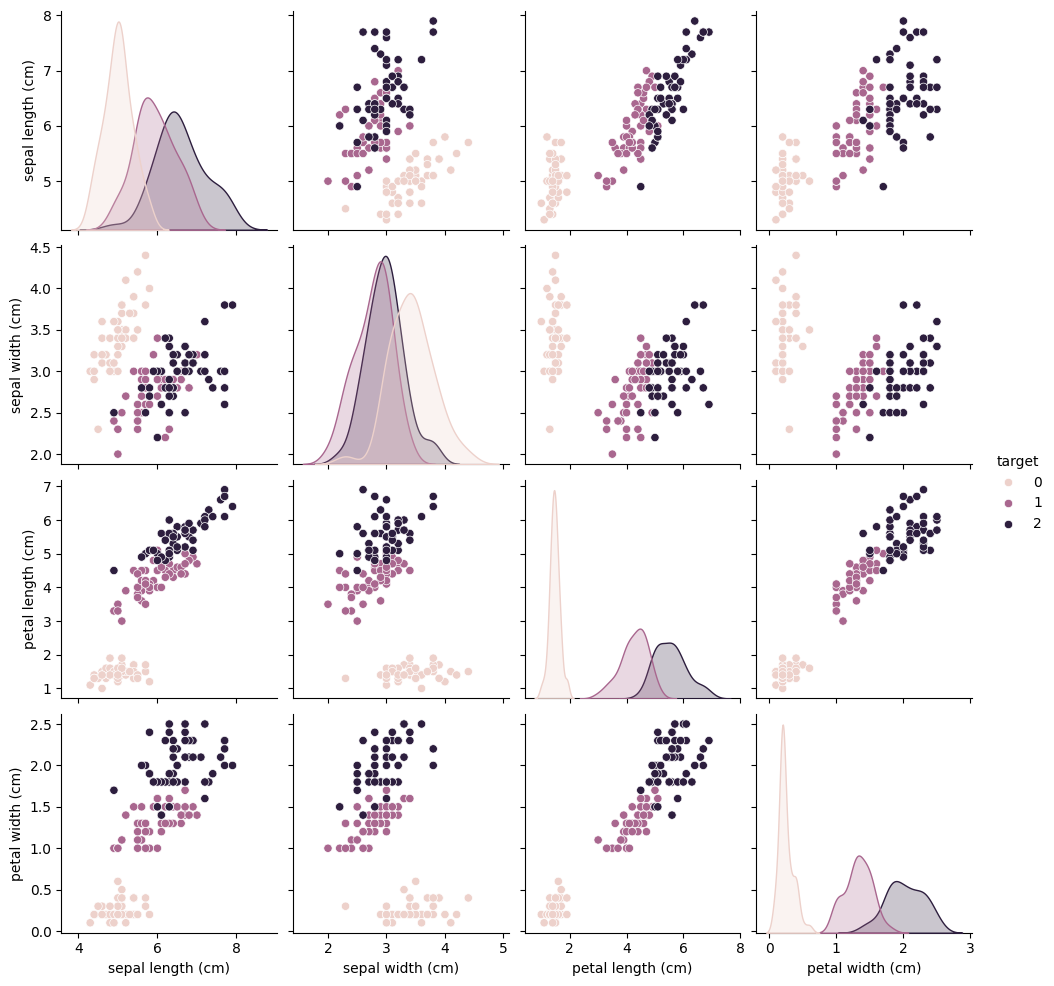

In [ ]:
sdfsdf = sns.pairplot(iris_data, hue='target', diag_kind="kde")
plt.show()

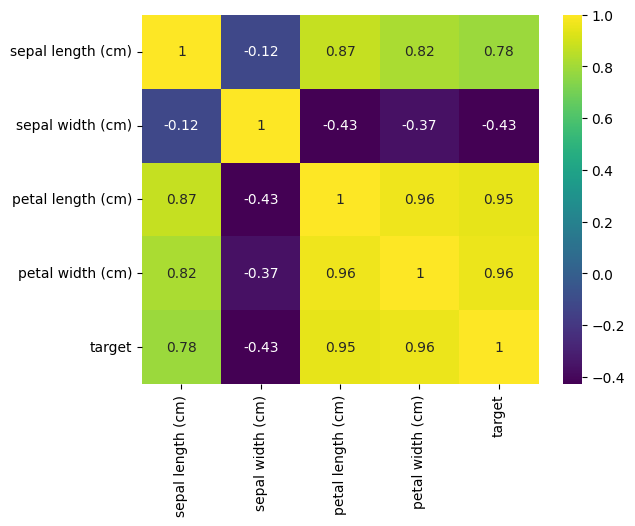

In [ ]:
sns.heatmap(iris_data.corr(), annot=True, cmap='viridis')
plt.show()

## Statistical Inference

In [ ]:
shapiro_wilk_mat = np.zeros((3, 4))
for i in iris_data['target'].unique():
  for j, feat in enumerate(data.feature_names):
    shapiro_wilk_mat[i, j] = stats.shapiro(iris_data.loc[iris_data['target']==i, feat])[1]
shapiro_wilk_p_values = pd.DataFrame(shapiro_wilk_mat, index=data.target_names, columns=data.feature_names)
#sign_lvl = 0.1
shapiro_wilk_p_values

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.459513,0.271526,0.054811,8.658573e-07
versicolor,0.464737,0.337995,0.158478,2.727780e-02
virginica,0.258315,0.180896,0.109775,8.695419e-02


/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


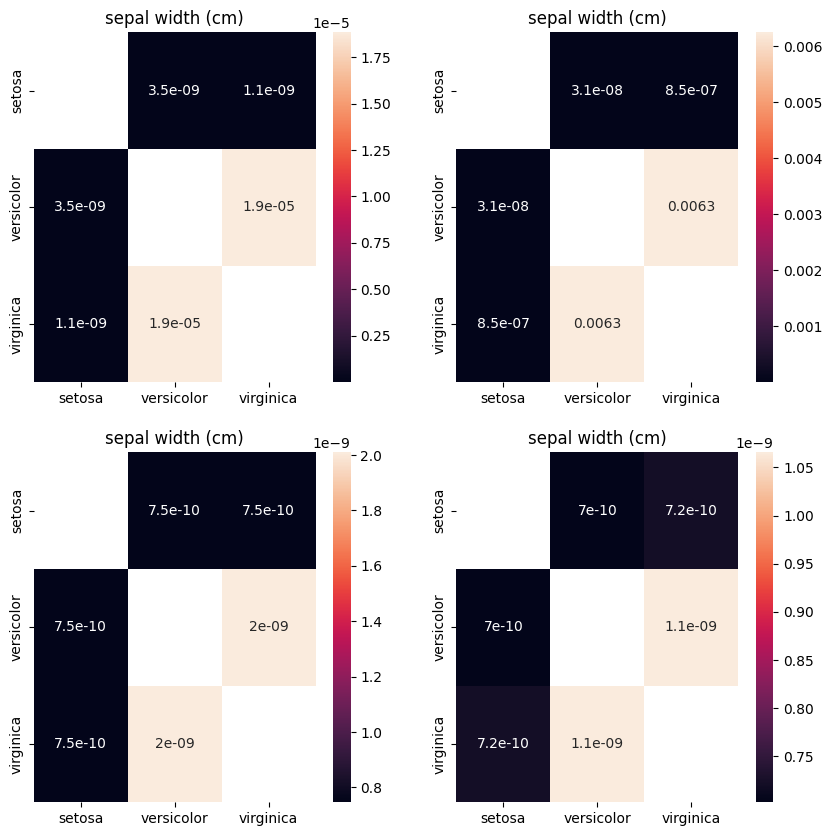

In [ ]:
mean_p_values = np.zeros((3, 3, 4))
for k, feat in enumerate(data.feature_names):
  for i in iris_data['target'].unique():
    for j in iris_data['target'].unique():
      mean_p_values[i, j, k] = stats.wilcoxon(iris_data.loc[iris_data['target']==i, feat],
                                              iris_data.loc[iris_data['target']==j, feat])[1]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
  sns.heatmap(pd.DataFrame(mean_p_values[:,:,i], index=data.target_names, columns=data.target_names), annot=True, ax=ax)
  ax.set_title(data.feature_names[1])
plt.show()

## Classification

4 types of models will trained and evaluated: k-nearest neighbours, logistic regression, support vector machine and decision tree. The evaluation metric used will be accuracy: the proportion of correct predictions out of the total predictions made by the model.

A base version of the models will be trained and evaluated at first. This will be followed by hyper-parameter optimization using a grid search technique with k-fold cross-validation in order to ultimately determine the most accurate predictive model while avoiding over-fitting.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
X = iris_data.drop('target', axis=1, inplace=False)

In [ ]:
y = iris_data['target'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
pipeline = Pipeline(steps=[('scaler', StandardScaler()), ('classifier', None)])
classifiers = [KNeighborsClassifier(), LogisticRegression(), SVC(), DecisionTreeClassifier()]
pipeline.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('classifier', None)],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'classifier': None,
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True}

In [ ]:
for model in classifiers:
  pipeline.set_params(classifier=model)
  pipeline.fit(X_train, y_train)
  pred_train = pipeline.predict(X_train)
  pred_test = pipeline.predict(X_test)
  print(model)
  print(f'Train Acc Score: {accuracy_score(y_train, pred_train)}')
  print(f'Test Acc Score: {accuracy_score(y_test, pred_test)} \n')

KNeighborsClassifier()
Train Acc Score: 0.9666666666666667
Test Acc Score: 1.0 

LogisticRegression()
Train Acc Score: 0.9666666666666667
Test Acc Score: 1.0 

SVC()
Train Acc Score: 0.9666666666666667
Test Acc Score: 1.0 

DecisionTreeClassifier()
Train Acc Score: 1.0
Test Acc Score: 1.0 



In [ ]:
grid = GridSearchCV(pipeline, param_grid=[{'classifier': [KNeighborsClassifier()],
                                           'classifier__n_neighbors': [1, 3, 5, 7, 9, 11, 13]},
                                          {'classifier': [LogisticRegression()],
                                           'classifier__C': [0.01, 0.1, 1, 10]},
                                          {'classifier': [SVC()],
                                           'classifier__kernel': ['linear', 'rbf', 'sigmoid', 'poly'],
                                           'classifier__C': [0.01, 0.1, 1, 2, 5, 10]},
                                          {'classifier': [DecisionTreeClassifier()],
                                           'classifier__criterion': ['gini', 'entropy', 'log_loss'],
                                           'classifier__splitter': ['best', 'random']}], cv=10)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
pred_train = best_model.predict(X_train)
pred_test = best_model.predict(X_test)
print(best_model)
print(grid.best_params_)
print(f'Train Acc Score: {accuracy_score(y_train, pred_train)}')
print(f'Test Acc Score: {accuracy_score(y_test, pred_test)} \n')

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(C=10))])
{'classifier': LogisticRegression(), 'classifier__C': 10}
Train Acc Score: 0.975
Test Acc Score: 1.0 



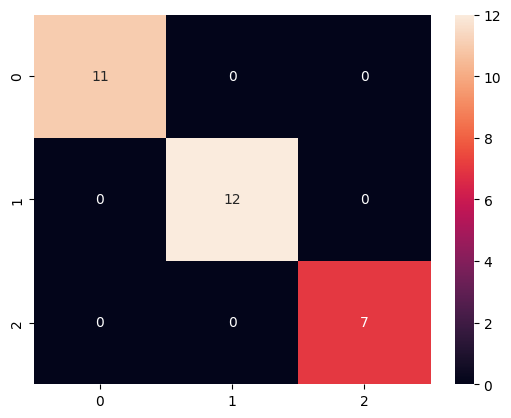

In [ ]:
conf_mat = confusion_matrix(y_test, pred_test)
sns.heatmap(conf_mat, annot=True)
plt.show()